# [1장 2강] - 실습: 핵심 모델과 선택 기준 압축 정리

## 실습 배경
- 데이터팀은 새 분류 과제에 사용할 첫 후보군을 정해야 합니다. 
- 같은 데이터에서도 Logistic Regression, KNN, Decision Tree의 결과가 다르고, label이 없는 데이터에서는 분류 지표 대신 군집 구조를 확인해야 합니다.
- 이번 실습에서는 하나의 모델을 정답처럼 외우지 않고, 데이터와 요구사항에 따라 후보를 비교하고 선택 근거를 남깁니다.
- 분류 모델 비교, label 없는 Wine 데이터의 구조 탐색, 데이터 조건별 후보 추천을 차례대로 수행한 뒤 최종 test 결과를 한 번 보고합니다.

## 실습 목표
- Logistic Regression·KNN·Decision Tree를 같은 분할과 지표로 비교할 수 있습니다.
- 거리 기반 모델에 scaling이 필요한 이유를 설명할 수 있습니다.
- validation AP 동률을 F1·Recall·고정 우선순위로 처리할 수 있습니다.
- K-means의 K 후보를 Silhouette로 비교하고 PCA 좌표를 시각화할 수 있습니다.
- target 유무·문제 유형·설명 필요성·희소 고차원 여부로 후보군을 바꿀 수 있습니다.
- validation에서 선택한 모델 family를 유지하고 test를 마지막에 한 번 평가할 수 있습니다.

## 오늘의 업무 흐름

```
문제 유형과 데이터 계약 확인
→ 동일 분할에서 분류 모델 비교
→ AP 동률 규칙으로 후보 선택
→ label 없는 군집 구조 탐색
→ 데이터 조건별 후보군 추천
→ 선택 모델 family 고정
→ 최종 test 보고
```

분류 문제의 고정 우선순위는 logistic → knn → tree입니다. AP·F1·Recall이 모두 같을 때만 이 순서를 사용합니다.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%pip install tabulate

from sklearn.datasets import load_breast_cancer, load_wine

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.pipeline import Pipeline

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    f1_score,
    recall_score,
    precision_score,
    silhouette_score,
)

SEED = 42

# =============== Breast cancer / 분류(0, 1) ===============
breast = load_breast_cancer(as_frame=True)
#scikit-learn의 데이터를 pandas 형태로 받아오는 옵션
# 반환된 객체(breast) 안의 데이터가 pandas 자료구조로 담김
# breast.data, breast.traget, breast.feature_names 등
# bunch는 scikit-leanr이 만든 자료형(속성 접근이 되는 딕셔너리)
X = breast.data
# 원본 target의 malignant(악성)=0을 탐지 대상인 postive class 1로 변환
y = (breast.target == 0 ).astype(int)

# 분할 전 y의 클래스 비율을 분할 후에도 유지
# X.shape # (569, 30)
# y.mean() # 0.37 -> 음성 대 양성 비율이 약 6:4
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size = 0.4,
    stratify=y,
    random_state=SEED
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=SEED
)

# =============== Wine ===============
wine = load_wine(as_frame=True)
wine_X = wine.data
wine_y = wine.target
wine_X.shape # (178, 13)
wine_y.value_counts()
# 1    71
# 0    59
# 2    48

print(f"Cancer - train: {len(X_train)}, valid: {len(X_valid)}, test: {len(X_test)}")
# Cancer - train: 341, valid: 114, test: 114

print(f"Cancer class rate - y: {round(float(y.mean()), 4)}, y_valid: {round(float(y_valid.mean()), 4)}, y_test: {round(float(y_test.mean()), 4)}")
# Cancer class rate - y: 0.3726, y_valid: 0.3772, y_test: 0.3684


Note: you may need to restart the kernel to use updated packages.
Cancer - train: 341, valid: 114, test: 114
Cancer class rate - y: 0.3726, y_valid: 0.3772, y_test: 0.3684


## 필수 1. 세 가지 분류 모델을 같은 조건에서 비교하기

### 문제 1-1: validation 모델 비교와 동률 처리
- 세 후보 모델 중 하나를 후속 실험에 사용할 모델 family로 정해야 합니다.
- 모델마다 다른 split을 사용하면 표본 차이와 모델 차이를 구분할 수 없으므로 같은 train과 validation을 사용하세요.
- 악성 탐지가 목적이므로 AP를 첫 기준으로 사용하고 동률 규칙까지 명시하세요.

### 수행해야 할 작업
1. Logistic Regression과 KNN에 `StandardScaler`를 포함하세요.
2. Decision Tree는 원래 특성 단위로 학습하세요.
3. 세 모델의 validation AP·F1·Recall을 계산하세요.
4. AP, F1, Recall 내림차순과 고정 우선순위 오름차순으로 정렬하세요.
5. 코드로 계산한 선택 결과와 같은 규칙의 `max()` 결과가 일치하는지 확인하세요.
6. 선택 모델의 장점과 이 데이터에서만 유효한 결과라는 한계를 작성하세요.

In [27]:
def compare_classifiers(models, X_train, y_train, X_valid, y_valid):

    results = []
    for name, model in models.items():
        model.fit(X_train, y_train)

        proba = model.predict_proba(X_valid)[:, 1] # y_hat (확률값)
        pred = model.predict(X_valid) # y_hat (결과값)

        recall = recall_score(y_valid, pred)
        precision = precision_score(y_valid, pred)
        f1 = f1_score(y_valid, pred)
        roc = roc_auc_score(y_valid, proba)
        ap = average_precision_score(y_valid, proba)

        results.append({
            "Name": name,
            "Recall": recall,
            "Precision": precision,
            "F1_Score": f1,
            "ROC-AUC": roc,
            "AP": ap,
        })

    # 성능지표는 내림차순, 우선순위는 오름차순
    df = pd.DataFrame(results)

    # AP·F1·Recall이 모두 같을 때만 이 순서를 사용
    priority = {"logistic": 1, "knn": 2, "tree": 3}
    df["Priority"] = df["Name"].map(priority)

    df_sorted = df.sort_values(
        by=["AP", "F1_Score", "Recall", "Priority"],
        ascending=[False, False, False, True]
        )

    # 정렬로 선택된 모델과 `max()` 결과가 일치하는지 확인
    choice_by_sort = df_sorted.iloc[0]["Name"]
    # max 함수는 가장 큰 값을 돌려준다.
    # max 함수의 대상이 되는건 우리가 만든 results(딕셔너리) 이다.
    # key 인자값으로 기준을 세운다.
    # Python은 튜플을 비교할 때 앞에서 부터 비교한다.
    choice_by_max = max(
        results,
        key=lambda r: (r["AP"], r["F1_Score"], r["Recall"], -priority[r["Name"]])
    )["Name"]
    assert choice_by_sort == choice_by_max
    # print(f"choice_by_sort: {choice_by_sort}, choice_by_max: {choice_by_max}")

    return df_sorted, choice_by_sort

In [28]:
models = {
    "logistic": Pipeline([
        # 최적의 log odds 값을 찾기 위해 경사하강법을 반복
        # 변화량이 tolerance 보다 작아짐 → 최적점에 수렴했다 판단 → 정상 종료
        # 아직 변화량이 큰데(=계속 내려가는 중인데) max_iter에 도달 → 강제 중단 → 경고
        # 1000은 관례적인 넉넉한 여유값
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=SEED))
    ]),
    "knn": Pipeline([
        # K에 해당하는 인자는 n_neighbors이고, 기본값은 5
        # random_state라는 매개변수가 존재하지 않음
        # 가장 가까운 이웃 K개를 찾아서 다수결 -> 결정론적
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier())
    ]),
    "tree": DecisionTreeClassifier(random_state=SEED)
}

result_table, selected_model = compare_classifiers(
    models, X_train, y_train, X_valid, y_valid
)

print(result_table.to_markdown(index=False))
print(f"\nselected_model: {selected_model}")

| Name     |   Recall |   Precision |   F1_Score |   ROC-AUC |       AP |   Priority |
|:---------|---------:|------------:|-----------:|----------:|---------:|-----------:|
| logistic | 0.930233 |        1    |   0.963855 |  1        | 1        |          1 |
| knn      | 0.883721 |        1    |   0.938272 |  0.995906 | 0.987888 |          2 |
| tree     | 0.883721 |        0.95 |   0.915663 |  0.927776 | 0.883395 |          3 |

selected_model: logistic


| Name     |   Recall |   Precision |   F1_Score |   ROC-AUC |       AP |   Priority |
|:---------|---------:|------------:|-----------:|----------:|---------:|-----------:|
| logistic | 0.930233 |        1    |   0.963855 |  1        | 1        |          1 |
| knn      | 0.883721 |        1    |   0.938272 |  0.995906 | 0.987888 |          2 |
| tree     | 0.883721 |        0.95 |   0.915663 |  0.927776 | 0.883395 |          3 |

- 선택된 모델은 logistic 이다.
- logistic 모델은 계수로 어떤 특성이 악성 판정에 얼마나 기여하는지 해석 및 설명이 가능한 장점이 있다.
- 임계값 0.5 기준에서 93%로 악성을 잡았고 7%는 놓지만 오탐(양성을 악성이라 판단)한 경우는 없었다.
- ROC-AUC, AP의 지표는 1로 악성과 양성의 순위가 완벽하다.
- 이는 임계값을 적절히 수정한다면 Precision의 손해를 최소화하면서 Recall을 끌어올릴 여지가 있다.
- 단 이 결과는 다른 분할과 새 데이터에서도 유지된다고 단정할 수 없다.

## 필수 2. label 없이 Wine 군집 구조 탐색하기

### 문제 2-1: K 후보 비교와 PCA 시각화
- Wine 데이터의 품종 label을 보지 않은 상태에서 화학 성분만으로 자연스러운 군집 구조가 있는지 확인해야 합니다.
- K를 임의로 하나 고정하지 말고 2부터 6까지 Silhouette를 비교하고, PCA 2차원 그림은 보조 자료로만 사용하세요.

1. Wine의 13개 수치 특성을 표준화하세요.
2. K=2부터 6까지 같은 seed로 K-means를 학습하세요.
3. 각 K의 Silhouette를 표로 만들고 가장 높은 K를 선택하세요.
4. PCA 2차원 좌표와 설명분산비를 계산하세요.
5. 선택 K의 군집 label로 산점도를 그리세요.
6. PCA 그림만으로 군집 품질을 확정하면 안 되는 이유를 작성하세요.

In [29]:
def explore_wine_clusters(wine_X, k_values=range(2, 7)):
    # Elbow, Silhouette는 K-means에서 K를 고르기 위한 방법이다.
    # Elbow: K를 늘려가며 군집 내부 응집도(관성)를 보고, 꺾이는 지점을 그래프로 찾는다.
    # Silhouette: 하나의 K에서 각 점의 응집도와 분리도를 계산해 점수를 내고 모든 점의 점수를 평균낸다.
    # 1에 가까울수록 응집도도 높고 분리도도 높은(=잘 뭉치고 잘 떨어진) 좋은 군집이다.

    # wine_X.shape # (178, 13)
    # wine_y.value_counts()
    # 1    71
    # 0    59
    # 2    48

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(wine_X)

    results = []
    labels_by_k = {}
    for k in k_values:
        # 아예 다른 시작점에서 n_init 번 처음부터 끝까지 돌려보고 그중 관성이 가장 낮은 k를 채택
        kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
        # 각 데이터 점이 몇 번 군집에 배정됐는지, 그 군집 번호들의 배열을 반환
        labels = kmeans.fit_predict(X_scaled)
        # a (응집도): 기준점 군집 안의 다른 모든 점까지 거리를 각각 재서 평균
        # b (분리도): 각 이웃 군집의 모든 점과 계산한 뒤, 가장 가까운 군집을 고른 값
        # s = (b - a)/max(a, b) -> 모든 점을 더해 평균을 낸 값이 silhouette_score
        score = silhouette_score(X_scaled, labels)
        # inertia(관성): 각 점에서 자기가 속한 군집의 중심점까지의 거리를 재서 제곱, 그걸 모든 점에 대해 더한 값
        # inertia = Σ ||x_i − μ_{c(i)}||² (x_i = 점, μ = 그 점이 속한 군집의 중심, c = 군집 label)
        # K-means가 학습 중에 줄이려고 애쓰던 목적함수 그 자체
        results.append({"k": k, "silhouette": score, "inertia": kmeans.inertia_})
        labels_by_k[k] = labels

    df= pd.DataFrame(results)
    best_k = max(results, key=lambda r: r["silhouette"])["k"]

    # PCA는 데이터가 가장 크게 퍼진 방향을 찾아서 새 축으로 삼는다.
    # 제1주성분(PC1)은 분산이 최대인 방향이며 데이터의 정보를 많이 담고 있다.
    # 제2주성분(PC2)은 PC1과 직교하면서 그다음으로 분산이 큰 방향이다.
    # Wine 특성이 13개, 즉 13차원임으로 2차원으로 줄여 본다.
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled) # 178x2 좌표
    # 설명분산비는 각 주성분이 원본 데이터의 전체 분산 중 몇 %를 담고 있는지 나타낸다.
    explained = pca.explained_variance_ratio_

    final_labels = labels_by_k[best_k]

    return df, X_pca, final_labels, best_k, explained
    

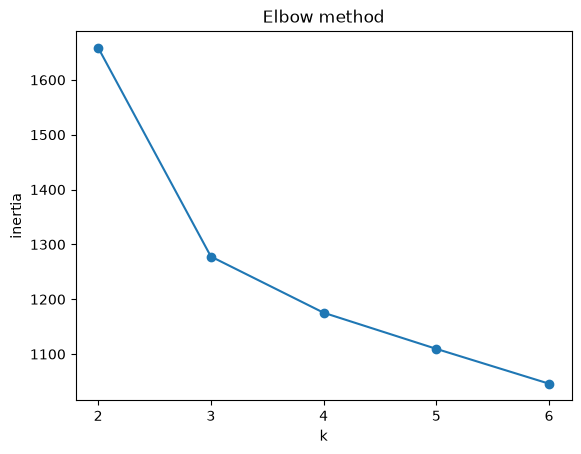

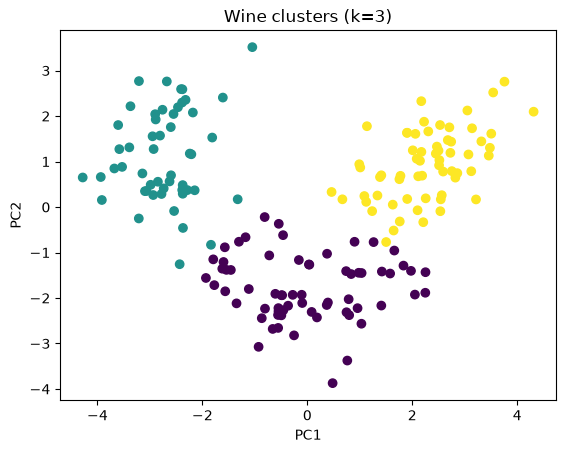

|   k |   silhouette |   inertia |
|----:|-------------:|----------:|
|   2 |     0.259317 |   1658.76 |
|   3 |     0.284859 |   1277.93 |
|   4 |     0.26017  |   1175.43 |
|   5 |     0.201619 |   1109.51 |
|   6 |     0.237167 |   1046    |

best_k: 3

PCA explained ratio: [0.36198848 0.1920749 ], 0.55


In [30]:
df, X_pca, final_labels, best_k, explained = explore_wine_clusters(wine_X)

plt.plot(df["k"], df["inertia"], marker="o")
plt.xlabel("k")
plt.ylabel("inertia")
plt.title("Elbow method")
plt.xticks(df["k"])
plt.show()

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=final_labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Wine clusters (k={best_k})")
plt.show()

print(df.to_markdown(index=False))
print(f"\nbest_k: {best_k}")
print(f"\nPCA explained ratio: {explained}, {round(explained[0] + explained[1], 2)}")

|   k |   silhouette |   inertia |
|----:|-------------:|----------:|
|   2 |     0.259317 |   1658.76 |
|   3 |     0.284859 |   1277.93 |
|   4 |     0.26017  |   1175.43 |
|   5 |     0.201619 |   1109.51 |
|   6 |     0.237167 |   1046    |

- silhouette는 k가 3일 때 최고 높은 점수로 응집도와 분리도가 가장 좋다.
- Elbow 그래프를 보면 k가 3에서 관성이 급락한 뒤 완만해진다.
- PCA 두 축은 전체 데이터의 55%를 설명하지만 나머지 45%의 정보가 담겨져 있지 않으므로 보조 자료로 사용한다.

## 심화 1. 데이터 조건에 따라 후보 모델 추천하기

### 문제 3-1: 추천 체크리스트와 최종 선택 모델 연결
- 동료가 데이터 조건과 무관하게 항상 같은 세 모델을 추천하는 함수를 작성했습니다.
- target 유무, 문제 유형, 설명 필요성, 희소 고차원 여부가 실제 후보 목록을 바꾸도록 수정하세요.
- 마지막에는 문제 1에서 선택한 바로 그 모델 family를 개발 데이터 전체에 학습하고 test를 한 번 평가하세요.

1. target이 없으면 KMeans·PCA와 비지도 검증 방법을 반환하세요.
2. 분류와 회귀에 서로 다른 기본 후보를 반환하세요.
3. 설명이 필요하면 선형 모델과 얕은 트리를 앞쪽에 배치하세요.
4. 희소 고차원 입력이면 선형 계열 후보로 목록을 바꾸세요.
5. 두 조건이 추천 결과를 실제로 바꾸는지 assertion으로 확인하세요.
6. 문제 1의 `selected_template`을 train+validation에 다시 학습하고 test AP·F1을 한 번 출력하세요.

In [31]:
def recommend_candidates(
        has_target,
        task=None,
        needs_explanation=False,
        sparse_high_dimensional=False,
):
    # 정답 label 유무
    if not has_target:
        return {
            "candidates": ["KMeans", "PCA"],
            "validation": "silhouette, pca.explained_variance_ratio_"
        }
    
    # 분류
    if task == "classification":

        # 특성이 엄청 많고 대부분 0인 경우
        if sparse_high_dimensional:
            candidates = ["LogisticRegression"]
        else:
            candidates = ["LogisticRegression"]

        # needs_explanation은 결과를 사람한테 설명해야 하냐
        if needs_explanation:
            candidates = ["LogisticRegression", "DecisionTreeClassifier"] + candidates

    # 회귀
    elif task == "regression":
        # 특성이 엄청 많고 대부분 0인 경우
        if sparse_high_dimensional:
            candidates = ["학습필요"]
        else:
            candidates = ["학습필요"]

        # needs_explanation은 결과를 사람한테 설명해야 하냐
        if needs_explanation:
            candidates = ["학습필요"] + candidates

    else:
        raise ValueError("task는 'classification' 또는 'regression'이어야 합니다.")

    return {"candidates": list(dict.fromkeys(candidates))[:3],
            "validation": "Predefined metric"}

In [36]:
# 모델 선택이 끝난 시점에 train과 valid를 합쳐 학습에 합류
X_dev = pd.concat([X_train, X_valid])
y_dev = pd.concat([y_train, y_valid])

# clone은 설정만 복사한 새 객체를 따로 생성
final_model = clone(models[selected_model]).fit(X_dev, y_dev)

test_probability = final_model.predict_proba(X_test)[:, 1]
test_ap = average_precision_score(y_test, test_probability)
test_f1 = f1_score(y_test, test_probability >= 0.5)

print(f"Selected Model: {selected_model}\n")

print(result_table)
print(f"\nTest AP: {test_ap}, F1 Score: {test_f1}")

Selected Model: logistic

       Name    Recall  Precision  F1_Score   ROC-AUC        AP  Priority
0  logistic  0.930233       1.00  0.963855  1.000000  1.000000         1
1       knn  0.883721       1.00  0.938272  0.995906  0.987888         2
2      tree  0.883721       0.95  0.915663  0.927776  0.883395         3

Test AP: 0.9944915072947418, F1 Score: 0.9629629629629629


- validation에서 선택한 logistic을 train+valid 전체로 재학습해 test로 한 번 평가한 결과, 
- AP 0.994·F1 0.963으로 validation과 거의 동일한 수준을 유지했다. 
- 이는 모델 선택이 특정 분할에 의존한 결과가 아니며, 새 데이터에도 일반화됨을 뒷받침한다.
- AP는 다양한 임계값에서 양성 샘플을 얼마나 높은 예측 확률 순으로 잘 정렬하는지를 평가한다.
- AP가 1에 가깝다는 건 양성 샘플에 높은 예측 확률을, 음성 샘플에 낮은 예측 확률을 부여하여
- 양성을 매우 정확하게 상위에 배치하고 있음을 의미한다.
- 학습된 모델이 낸 확률값을 높은 순으로 줄 세웠을 때, 진짜 양성들이 얼마나 앞쪽에 몰려 있느냐,
- 이 순위가 좋을수록 AP가 1에 가깝다